# Advanced Customer Churn Analysis

## Project: Customer Churn Business Analysis

This notebook performs advanced analysis to convert exploratory findings into actionable business insights.

### Objectives

- Identify high-priority customer segments
- Quantify churn risk using customer characteristics
- Compare churn across important business segments
- Translate analytical findings into business actions
- Provide measurable recommendations for customer retention

### Analysis Techniques

1. Customer risk segmentation
2. Segment-level churn analysis
3. Revenue exposure analysis
4. Retention opportunity analysis
5. Business KPI estimation

### Business Goal

The goal is to identify customer groups where targeted retention efforts could have the greatest potential business impact.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
DATA_PATH = "../data/cleaned_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 500
Columns: 9


In [12]:
# Create tenure groups
tenure_bins = [0, 12, 24, 48, float("inf")]
tenure_labels = [
    "0-12 Months",
    "13-24 Months",
    "25-48 Months",
    "49+ Months"
]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Create monthly charge segments using the median
charge_median = df["MonthlyCharges"].median()

df["ChargeSegment"] = np.where(
    df["MonthlyCharges"] >= charge_median,
    "High Monthly Charges",
    "Low Monthly Charges"
)

print(f"Monthly charge median: {charge_median}")

Monthly charge median: 115.0


In [13]:
segment_analysis = (
    df.groupby(["Contract", "TenureGroup"])
    .agg(
        Customers=("CustomerID", "count"),
        Churned=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

segment_analysis["Churn_Rate"] *= 100

segment_analysis = segment_analysis.sort_values(
    "Churn_Rate",
    ascending=False
)

segment_analysis

,Contract,TenureGroup,Customers,Churned,Churn_Rate
0,Month-to-month,0-12 Months,35,35,100.000000
8,Two year,0-12 Months,23,10,43.478261
4,One year,0-12 Months,26,8,30.769231
1,Month-to-month,13-24 Months,23,0,0.000000
3,Month-to-month,49+ Months,66,0,0.000000
2,Month-to-month,25-48 Months,46,0,0.000000
6,One year,25-48 Months,73,0,0.000000
5,One year,13-24 Months,27,0,0.000000
7,One year,49+ Months,60,0,0.000000
9,Two year,13-24 Months,25,0,0.000000


## Segment-Level Churn Analysis

Combining contract type and tenure provides a more detailed view of customer churn.

The highest-risk segment is the **month-to-month customers with 0–12 months of tenure**. This segment contains 35 customers, of whom all 35 churned, resulting in an observed churn rate of 100%.

Other customers within the first 12 months also show elevated churn:

- Two-year contract: 43.48%
- One-year contract: 30.77%
- Month-to-month contract: 100.00%

In contrast, customers with more than 12 months of tenure recorded no churn in this dataset.

### Business Insight

The combination of **early tenure and contract type** provides a useful basis for prioritizing retention activities.

The business should focus its strongest retention efforts on newly acquired customers, particularly those on month-to-month contracts.

Because the dataset shows an unusually concentrated churn pattern, these findings should be validated using larger and more representative real-world data before implementation.

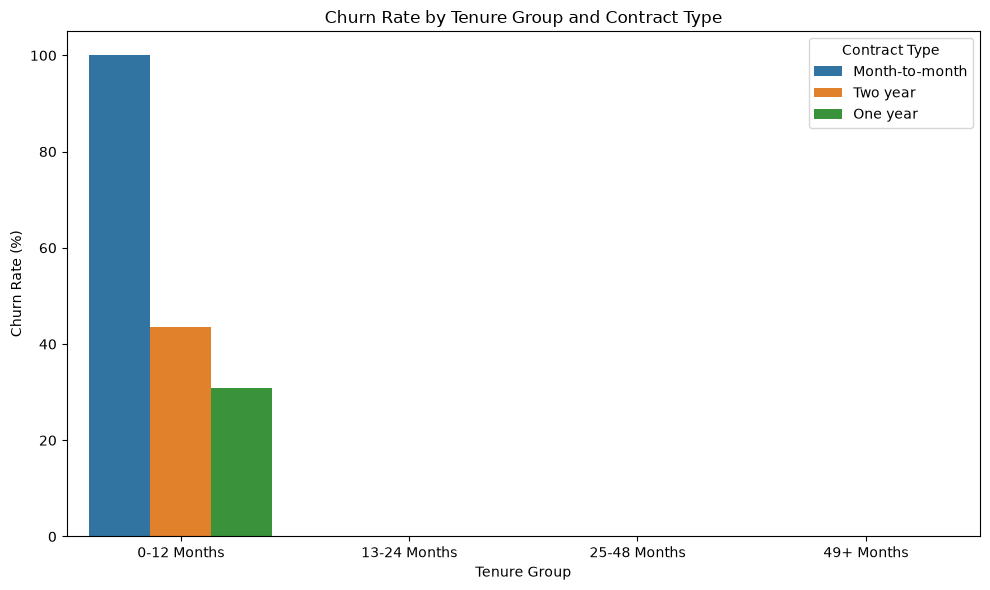

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_analysis,
    x="TenureGroup",
    y="Churn_Rate",
    hue="Contract"
)

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Contract Type")
plt.tight_layout()
plt.show()

In [15]:
high_risk_segment = segment_analysis[
    (segment_analysis["Contract"] == "Month-to-month") &
    (segment_analysis["TenureGroup"] == "0-12 Months")
]

high_risk_segment

,Contract,TenureGroup,Customers,Churned,Churn_Rate
0,Month-to-month,0-12 Months,35,35,100.0


In [16]:
high_risk_customers = int(high_risk_segment["Customers"].iloc[0])
high_risk_churned = int(high_risk_segment["Churned"].iloc[0])

print(f"High-risk customers: {high_risk_customers}")
print(f"Observed churned customers: {high_risk_churned}")

High-risk customers: 35
Observed churned customers: 35


## Retention Opportunity Scenario

To estimate the potential impact of a targeted retention program, three hypothetical retention scenarios are considered for the highest-risk segment.

The scenarios assume that the business could successfully retain 20%, 30%, or 40% of the observed churned customers in this segment.

These are scenario estimates, not predictions of actual future retention.

In [17]:
retention_rates = [0.20, 0.30, 0.40]

retention_scenarios = pd.DataFrame({
    "Retention Scenario": ["20%", "30%", "40%"],
    "Retention Rate": retention_rates
})

retention_scenarios["Potential Customers Retained"] = (
    high_risk_churned * retention_scenarios["Retention Rate"]
).round().astype(int)

retention_scenarios["Customers Potentially Lost"] = (
    high_risk_churned -
    retention_scenarios["Potential Customers Retained"]
)

retention_scenarios

,Retention Scenario,Retention Rate,Potential Customers Retained,Customers Potentially Lost
0,20%,0.2,7,28
1,30%,0.3,10,25
2,40%,0.4,14,21


### Business Interpretation

The scenario analysis demonstrates the potential value of targeted retention.

If the business could retain approximately:

- **20%** of the observed churned customers → around **7 customers**
- **30%** → around **10 customers**
- **40%** → around **14 customers**

from the highest-risk segment, the business could potentially prevent a meaningful number of customer losses.

These figures are hypothetical scenarios based on the current dataset. Actual retention impact would depend on campaign effectiveness, customer response, costs, and other business factors.

## Revenue Exposure Analysis

Customer retention is not only about customer counts. Customers with higher monthly charges represent greater recurring revenue exposure if they churn.

This analysis estimates the monthly charges associated with the highest-risk customer segment.

The calculation represents revenue exposure based on the dataset's MonthlyCharges field. It should not be interpreted as actual company revenue because the dataset does not specify currency, discounts, costs, or other financial adjustments.

In [18]:
# Calculate monthly charge exposure for the highest-risk segment

high_risk_customer_ids = df[
    (df["Contract"] == "Month-to-month") &
    (df["TenureGroup"] == "0-12 Months")
]

high_risk_revenue = high_risk_customer_ids["MonthlyCharges"].sum()
average_high_risk_charge = high_risk_customer_ids["MonthlyCharges"].mean()

print(f"High-risk customers: {len(high_risk_customer_ids)}")
print(f"Average monthly charge: {average_high_risk_charge:.2f}")
print(f"Total monthly charge exposure: {high_risk_revenue:.2f}")

High-risk customers: 35
Average monthly charge: 120.94
Total monthly charge exposure: 4233.00


# Final Business Impact Summary

The advanced analysis translates the statistical findings into practical business priorities.

## Key Findings

### Customer Churn
The overall churn rate is 10.60%, with 53 churned customers out of 500.

### Highest-Risk Segment
The highest-risk segment consists of month-to-month customers with 0–12 months of tenure.

- Customers: 35
- Observed churned: 35
- Observed churn rate: 100%

### Revenue Exposure
This highest-risk segment has:

- Average monthly charge: 120.94
- Total monthly charge exposure: 4,233.00

### Retention Opportunity

Scenario analysis indicates that retaining:

- 20% could retain approximately 7 customers
- 30% could retain approximately 10 customers
- 40% could retain approximately 14 customers

These are hypothetical scenarios intended to demonstrate potential business impact.

## Recommended Business Priorities

1. **Strengthen first-year customer onboarding**
   - Introduce 30/60/90-day engagement checkpoints.
   - Identify dissatisfaction early.
   - Provide proactive support.

2. **Target month-to-month customers**
   - Offer appropriate incentives for longer-term contracts.
   - Communicate the benefits of longer commitments.
   - Prioritize customers showing additional risk indicators.

3. **Prioritize high-risk customers**
   - Use the risk segmentation framework to prioritize retention resources.
   - Provide personalized outreach rather than generic campaigns.

4. **Review high monthly-charge customers**
   - Investigate whether customers perceive sufficient value for their charges.
   - Consider personalized plans or service reviews.

5. **Measure retention program performance**
   - Track churn rate.
   - Track contract conversion.
   - Track retention rate.
   - Track campaign response.
   - Track customers retained.

## Final Conclusion

The analysis indicates that customer churn is strongly concentrated around early tenure and is particularly pronounced among month-to-month customers.

A risk-based retention strategy focused on early-tenure and month-to-month customers can help the business prioritize limited retention resources.

The findings are based on the available 500-customer dataset. The unusually concentrated churn pattern should be validated using larger and more representative real-world data before production implementation.